# 2D Floodway Encroachment


In [1]:
# !pip install --upgrade ras-commander
from pathlib import Path
import logging
import shutil
import urllib.request
import zipfile

import geopandas as gpd
import h5py
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import MultiPolygon, Polygon, box

from ras_commander import RasCmdr, RasEncroachments, RasMap, RasPrj, init_ras_project
from ras_commander.hdf import HdfMesh, HdfResultsMesh

logging.getLogger().setLevel(logging.WARNING)
logging.getLogger("ras_commander").setLevel(logging.WARNING)

print("ras-commander 2D floodway encroachment workflow imports loaded")

ras-commander 2D floodway encroachment workflow imports loaded


# Local Source Development

The committed import cell above is pip-mode. For local ras-commander development, execute this notebook from the repository root with `PYTHONPATH` set to the active checkout, for example:

```powershell
$env:PYTHONPATH=(Get-Location).Path
conda run --no-capture-output -n symphony-dev python -m jupyter nbconvert --to notebook --execute examples/311_2d_floodway_encroachment.ipynb --inplace
```

Generated HEC-RAS projects and maps are written under `working/311_2d_floodway_encroachment/`, which is ignored by git.

# 2D Floodway Encroachment Authoring

This notebook follows the HEC zones tutorial pattern using ras-commander APIs: copy the official 2D floodway example, clone the Base plan, author zones and encroachment regions from structured polygon inputs, register RASMapper layers, run the base and encroached plans, and plot maximum WSE difference.

In [2]:
OFFICIAL_TUTORIAL_URL = "https://www.hec.usace.army.mil/confluence/rasdocs/hgt/latest/tutorials/2d-unsteady-flow/floodway-encroachment-analysis-using-zones"
OFFICIAL_ZIP_URL = "https://www.hec.usace.army.mil/confluence/rasdocs/hgt/files/latest/308220916/308220921/1/1753461426299/Example_2DFloodways.zip"

RAS_VERSION = "6.6"
BASE_PLAN = "02"
TARGET_RISE_FT = 1.0
FILL_SLOPE = 0.001
ADDITIONAL_FILL_FT = 0.0
NUM_CORES = 2
FORCE_RERUN = True

cwd = Path.cwd()
repo_root = None
for candidate in [cwd, *cwd.parents]:
    if (candidate / ".git").exists() and (candidate / "ras_commander").exists():
        repo_root = candidate
        break
if repo_root is None:
    repo_root = cwd

working_root = repo_root / "working" / "311_2d_floodway_encroachment"
project_folder = working_root / "Example_2DFloodways"

print(f"Official tutorial: {OFFICIAL_TUTORIAL_URL}")
print(f"Working folder: {working_root}")

Official tutorial: https://www.hec.usace.army.mil/confluence/rasdocs/hgt/latest/tutorials/2d-unsteady-flow/floodway-encroachment-analysis-using-zones
Working folder: C:\GH\symphony-workspaces\ras-commander\CLB-317\working\311_2d_floodway_encroachment


In [3]:
def find_official_project() -> Path:
    candidates = [
        Path(r"H:/Symphony/ras-commander/CLB-317/Example_2DFloodways"),
        Path(r"H:/Symphony/ras-commander/CLB-317/official_hec_examples/Example_2DFloodways/Example_2DFloodways"),
    ]
    for candidate in candidates:
        if (candidate / "Example2DFloodway.prj").exists():
            return candidate

    working_root.mkdir(parents=True, exist_ok=True)
    zip_path = working_root / "Example_2DFloodways.zip"
    if not zip_path.exists():
        print(f"Downloading official HEC tutorial data to {zip_path}")
        urllib.request.urlretrieve(OFFICIAL_ZIP_URL, zip_path)

    extract_root = working_root / "official_source"
    if not extract_root.exists():
        with zipfile.ZipFile(zip_path) as zf:
            zf.extractall(extract_root)

    matches = list(extract_root.rglob("Example2DFloodway.prj"))
    if not matches:
        raise FileNotFoundError("Could not locate Example2DFloodway.prj in official tutorial data")
    return matches[0].parent

source_project = find_official_project()
print(f"Source project: {source_project}")

working_root.mkdir(parents=True, exist_ok=True)
resolved_working = working_root.resolve()
if project_folder.exists():
    resolved_project = project_folder.resolve()
    if not resolved_project.is_relative_to(resolved_working):
        raise RuntimeError(f"Refusing to delete outside working folder: {resolved_project}")
    shutil.rmtree(project_folder)

shutil.copytree(source_project, project_folder, ignore=shutil.ignore_patterns("*.GIS.hdf", "Calculated Layers"))
print(f"Copied project to: {project_folder}")

Source project: H:\Symphony\ras-commander\CLB-317\Example_2DFloodways
Copied project to: C:\GH\symphony-workspaces\ras-commander\CLB-317\working\311_2d_floodway_encroachment\Example_2DFloodways


In [4]:
project = RasPrj()
init_ras_project(project_folder, RAS_VERSION, ras_object=project, load_results_summary=False)

plan_summary = project.plan_df[["plan_number", "Plan Title", "Short Identifier", "Geom File", "Flow File", "HDF_Results_Path"]]
plan_summary

,plan_number,Plan Title,Short Identifier,Geom File,Flow File,HDF_Results_Path
0,01,Initial,Initial,01,01,C:\GH\symphony-workspaces\ras-commander\CLB-31...
1,02,Base,Base,01,01,C:\GH\symphony-workspaces\ras-commander\CLB-31...


In [5]:
geom_hdf = project_folder / "Example2DFloodway.g01.hdf"
mesh_areas = HdfMesh.get_mesh_areas(geom_hdf)
mesh_cells = HdfMesh.get_mesh_cell_polygons(geom_hdf)
mesh_area = mesh_areas.iloc[0].geometry
minx, miny, maxx, maxy = mesh_area.bounds
width = maxx - minx
height = maxy - miny

print(f"Mesh areas: {len(mesh_areas)}")
print(f"Mesh cells: {len(mesh_cells):,}")
print(f"CRS: {mesh_areas.crs}")
print(f"Bounds: {minx:.1f}, {miny:.1f}, {maxx:.1f}, {maxy:.1f}")

Mesh areas: 1
Mesh cells: 12,277
CRS: EPSG:2276
Bounds: 2262450.3, 6934657.3, 2297190.8, 6953351.7


In [6]:
def _parts_from_geometry(geometry):
    if geometry.is_empty:
        return []
    if isinstance(geometry, Polygon):
        return [[[float(x), float(y)] for x, y in geometry.exterior.coords]]
    if isinstance(geometry, MultiPolygon):
        parts = []
        for poly in geometry.geoms:
            parts.extend(_parts_from_geometry(poly))
        return parts
    raise TypeError(f"Unsupported polygon geometry: {geometry.geom_type}")

pad_x = width * 0.03
pad_y = height * 0.08

zone_geoms = [
    box(minx + pad_x, miny + pad_y, minx + width / 3, maxy - pad_y).intersection(mesh_area),
    box(minx + width / 3, miny + pad_y, minx + 2 * width / 3, maxy - pad_y).intersection(mesh_area),
    box(minx + 2 * width / 3, miny + pad_y, maxx - pad_x, maxy - pad_y).intersection(mesh_area),
]
region_geoms = [
    box(minx + pad_x, miny + pad_y * 1.3, maxx - pad_x, miny + height * 0.36).intersection(mesh_area),
    box(minx + pad_x, maxy - height * 0.36, maxx - pad_x, maxy - pad_y * 1.3).intersection(mesh_area),
]

zones = [
    {"name": "Upstream Zone", "parts": _parts_from_geometry(zone_geoms[0]), "value": 2.4},
    {"name": "Middle Zone", "parts": _parts_from_geometry(zone_geoms[1]), "value": 2.0},
    {"name": "Downstream Zone", "parts": _parts_from_geometry(zone_geoms[2]), "value": 1.6},
]
regions = [
    {"name": "Left Floodplain Fill", "parts": _parts_from_geometry(region_geoms[0])},
    {"name": "Right Floodplain Fill", "parts": _parts_from_geometry(region_geoms[1])},
]

pd.DataFrame(
    {
        "feature": [r["name"] for r in regions] + [z["name"] for z in zones],
        "type": ["region"] * len(regions) + ["zone"] * len(zones),
        "parts": [len(r["parts"]) for r in regions] + [len(z["parts"]) for z in zones],
        "zone_value": [None] * len(regions) + [z["value"] for z in zones],
    }
)

,feature,type,parts,zone_value
0,Left Floodplain Fill,region,1,NaN
1,Right Floodplain Fill,region,1,NaN
2,Upstream Zone,zone,1,2.4
3,Middle Zone,zone,1,2.0
4,Downstream Zone,zone,1,1.6


In [7]:
setup = RasEncroachments.setup_2d_floodway_encroachment_plan(
    BASE_PLAN,
    base_plan=BASE_PLAN,
    new_plan_shortid="Encroached",
    new_title="Encroached",
    target_rise=TARGET_RISE_FT,
    default_fill_slope=FILL_SLOPE,
    default_additional_fill=ADDITIONAL_FILL_FT,
    regions=regions,
    zones=zones,
    add_depth_velocity_map=True,
    depth_velocity_plan_name="Base",
    terrain_name="USGSTerrain",
    ras_object=project,
)

ENCROACHED_PLAN = setup["plan_number"]
print(f"Encroached plan number: {ENCROACHED_PLAN}")
print(f"Plan file: {setup['plan_path']}")
print(f"Editable GIS HDF: {setup['gis_hdf_path']}")
print(setup["settings"])

readback_regions = RasEncroachments.list_2d_encroachment_regions(ENCROACHED_PLAN, ras_object=project)
readback_zones = RasEncroachments.list_2d_encroachment_zones(ENCROACHED_PLAN, ras_object=project)

readback_regions[["name", "fill_slope", "additional_fill_rise", "part_count", "point_count"]]

Encroached plan number: 03
Plan file: C:\GH\symphony-workspaces\ras-commander\CLB-317\working\311_2d_floodway_encroachment\Example_2DFloodways\Example2DFloodway.p03
Editable GIS HDF: C:\GH\symphony-workspaces\ras-commander\CLB-317\working\311_2d_floodway_encroachment\Example_2DFloodways\Example2DFloodway.p03.GIS.hdf
{'base_plan_filename': '.\\Example2DFloodway.p02', 'maximum_target_rise': 1.0, 'fill_slope': 0.0010000000474974513, 'additional_fill': 0.0, 'source_hdf': 'C:\\GH\\symphony-workspaces\\ras-commander\\CLB-317\\working\\311_2d_floodway_encroachment\\Example_2DFloodways\\Example2DFloodway.p03.GIS.hdf'}


,name,fill_slope,additional_fill_rise,part_count,point_count
0,Left Floodplain Fill,0.001,0.0,1,61
1,Right Floodplain Fill,0.001,0.0,1,71


In [8]:
readback_zones[["name", "value", "part_count", "point_count"]]

,name,value,part_count,point_count
0,Upstream Zone,2.4,1,92
1,Middle Zone,2.0,1,111
2,Downstream Zone,1.6,1,68


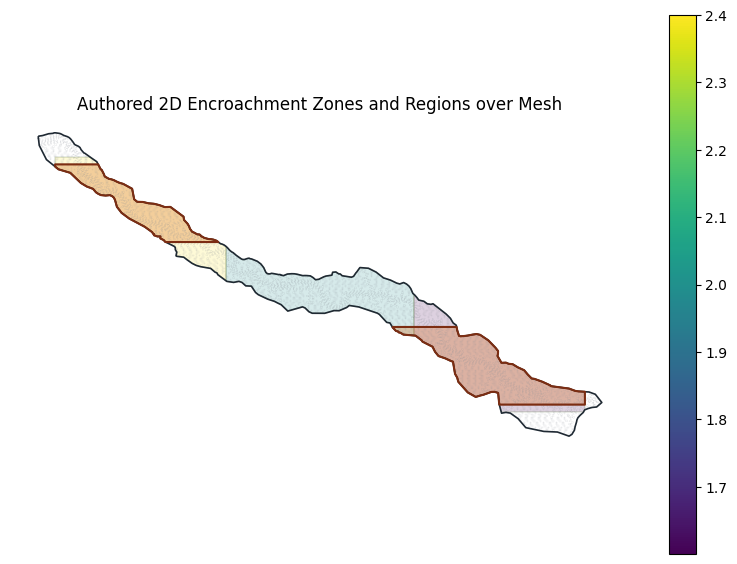

In [9]:
def _geometry_from_parts(parts):
    polygons = [Polygon(part) for part in parts if len(part) >= 4]
    if len(polygons) == 1:
        return polygons[0]
    return MultiPolygon(polygons)

regions_gdf = gpd.GeoDataFrame(
    readback_regions[["name", "fill_slope", "additional_fill_rise"]].copy(),
    geometry=[_geometry_from_parts(parts) for parts in readback_regions["parts"]],
    crs=mesh_areas.crs,
)
zones_gdf = gpd.GeoDataFrame(
    readback_zones[["name", "value"]].copy(),
    geometry=[_geometry_from_parts(parts) for parts in readback_zones["parts"]],
    crs=mesh_areas.crs,
)

cell_step = max(len(mesh_cells) // 3000, 1)
fig, ax = plt.subplots(figsize=(10, 7))
mesh_cells.iloc[::cell_step].boundary.plot(ax=ax, color="#8a8f98", linewidth=0.15, alpha=0.45)
mesh_areas.boundary.plot(ax=ax, color="#1f2933", linewidth=1.2)
zones_gdf.plot(ax=ax, column="value", cmap="viridis", alpha=0.18, edgecolor="#365314", linewidth=1.0, legend=True)
regions_gdf.plot(ax=ax, facecolor="#d95f02", edgecolor="#7c2d12", alpha=0.28, linewidth=1.2)
regions_gdf.boundary.plot(ax=ax, color="#7c2d12", linewidth=1.5)
ax.set_title("Authored 2D Encroachment Zones and Regions over Mesh")
ax.set_aspect("equal")
ax.set_axis_off()
plt.show()

In [10]:
run_rows = []
for plan in [BASE_PLAN, ENCROACHED_PLAN]:
    result = RasCmdr.compute_plan(
        plan,
        ras_object=project,
        force_rerun=FORCE_RERUN,
        verify=True,
        num_cores=NUM_CORES,
    )
    run_rows.append({"plan": plan, "success": bool(result)})

run_df = pd.DataFrame(run_rows)
run_df

,plan,success
0,02,True
1,03,True


In [11]:
base_result_layer = RasMap.ensure_results_plan_layer(BASE_PLAN, name="Base", ras_object=project)
enc_result_layer = RasMap.ensure_results_plan_layer(ENCROACHED_PLAN, name="Encroached", ras_object=project)
comparison_layers = RasMap.add_wse_comparison_layers(
    plan_pairs=[{"exist_plan": "Base", "prop_plan": "Encroached", "tag": "Encroached"}],
    exist_terrain="USGSTerrain",
    prop_terrain="USGSTerrain",
    layer_name_template="WSE_Rise_{tag}",
    host_plan="proposed",
    ras_object=project,
)

pd.DataFrame(
    [
        {"layer_type": "result", **base_result_layer},
        {"layer_type": "result", **enc_result_layer},
        {"layer_type": "calculated", "name": comparison_layers[0], "filename": "Calculated Layers/WSE_Rise_Encroached.rasscript"},
    ]
)

,layer_type,name,filename,checked,expanded,rasmap_path
0,result,Base,.\Example2DFloodway.p02.hdf,True,True,C:\GH\symphony-workspaces\ras-commander\CLB-31...
1,result,Encroached,.\Example2DFloodway.p03.hdf,True,True,C:\GH\symphony-workspaces\ras-commander\CLB-31...
2,calculated,WSE_Rise_Encroached,Calculated Layers/WSE_Rise_Encroached.rasscript,NaN,NaN,NaN


In [12]:
base_hdf = project_folder / "Example2DFloodway.p02.hdf"
enc_hdf = project_folder / f"Example2DFloodway.p{ENCROACHED_PLAN}.hdf"

base_ws = HdfResultsMesh.get_mesh_max_ws(base_hdf)
enc_ws = HdfResultsMesh.get_mesh_max_ws(enc_hdf)
cols = ["mesh_name", "cell_id", "maximum_water_surface"]
wse_delta = enc_ws[["mesh_name", "cell_id", "maximum_water_surface", "geometry"]].merge(
    base_ws[cols],
    on=["mesh_name", "cell_id"],
    suffixes=("_encroached", "_base"),
)
wse_delta["wse_rise_ft"] = wse_delta["maximum_water_surface_encroached"] - wse_delta["maximum_water_surface_base"]
wse_delta = gpd.GeoDataFrame(wse_delta, geometry="geometry", crs=enc_ws.crs)

with h5py.File(enc_hdf, "r") as hdf:
    has_native_unsteady_encroachment_results = "Results/Unsteady/Unsteady Encroachment/Results" in hdf

print(f"Native unsteady encroachment result arrays present: {has_native_unsteady_encroachment_results}")
print(wse_delta["wse_rise_ft"].describe().to_string())

Native unsteady encroachment result arrays present: False
count    13093.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0


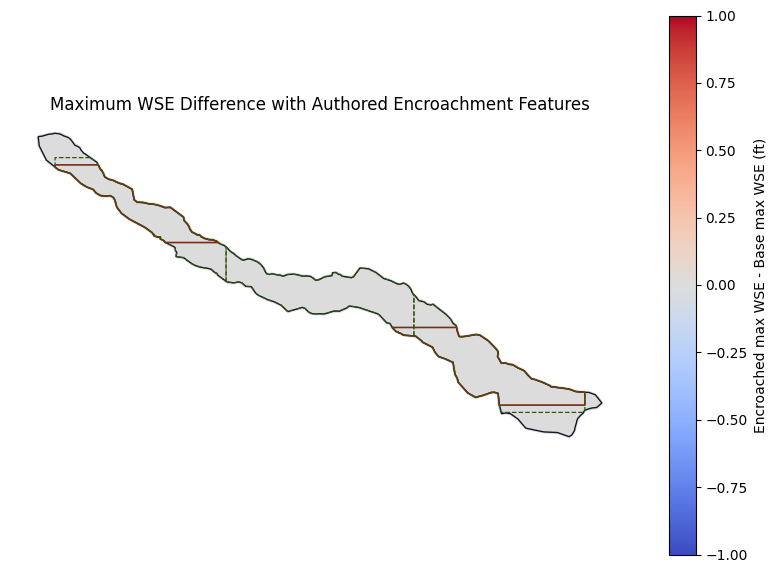

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))
wse_delta.plot(
    ax=ax,
    column="wse_rise_ft",
    cmap="coolwarm",
    markersize=2,
    vmin=-1.0,
    vmax=1.0,
    legend=True,
    legend_kwds={"label": "Encroached max WSE - Base max WSE (ft)"},
)
mesh_areas.boundary.plot(ax=ax, color="#111827", linewidth=1.0)
regions_gdf.boundary.plot(ax=ax, color="#7c2d12", linewidth=1.2)
zones_gdf.boundary.plot(ax=ax, color="#365314", linewidth=0.9, linestyle="--")
ax.set_title("Maximum WSE Difference with Authored Encroachment Features")
ax.set_aspect("equal")
ax.set_axis_off()
plt.show()

## Notes

The workflow above covers the core setup required by the 2D floodway tutorials without GUI-only authoring steps: the model is copied, the Base plan is cloned, regions and zones round-trip through `RasEncroachments`, editable RASMapper plan layers are registered, the Depth * Velocity result map is added, both plans are computed through `RasCmdr`, and a WSE comparison layer plus direct HDF difference plot are created.

The executed run records whether HEC-RAS wrote native `Results/Unsteady/Unsteady Encroachment` arrays. On this workstation's command-line run, HEC-RAS 6.6 completed the plan but did not materialize those native arrays, so the direct max-WSE delta is the auditable comparison output from the computed HDFs.